# Visualizing Data with Bar Charts

**Author:** Mitadru Deb  \
**Date:** February 2026

This notebook demonstrates multiple visualization techniques (histogram, box plot, scatter plot, bubble plot, and various bar charts) using the Stack Overflow survey dataset.

The focus is on bar charts for composition and comparison across categories.

## Importing Libraries

I'll import the libraries needed for data analysis and plotting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Loading the Dataset

I'll download and load the survey data into a pandas DataFrame.

In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(url)

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Helper: Age conversion

The dataset stores `Age` as ranges, so I'll map those ranges to representative numeric values for numeric charts.

In [3]:
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}
df['Age_numeric'] = df['Age'].map(age_mapping)

## Task 1: Visualizing Data Distributions

### 1) Histogram of `ConvertedCompYearly`
I'll visualize the distribution of yearly compensation.

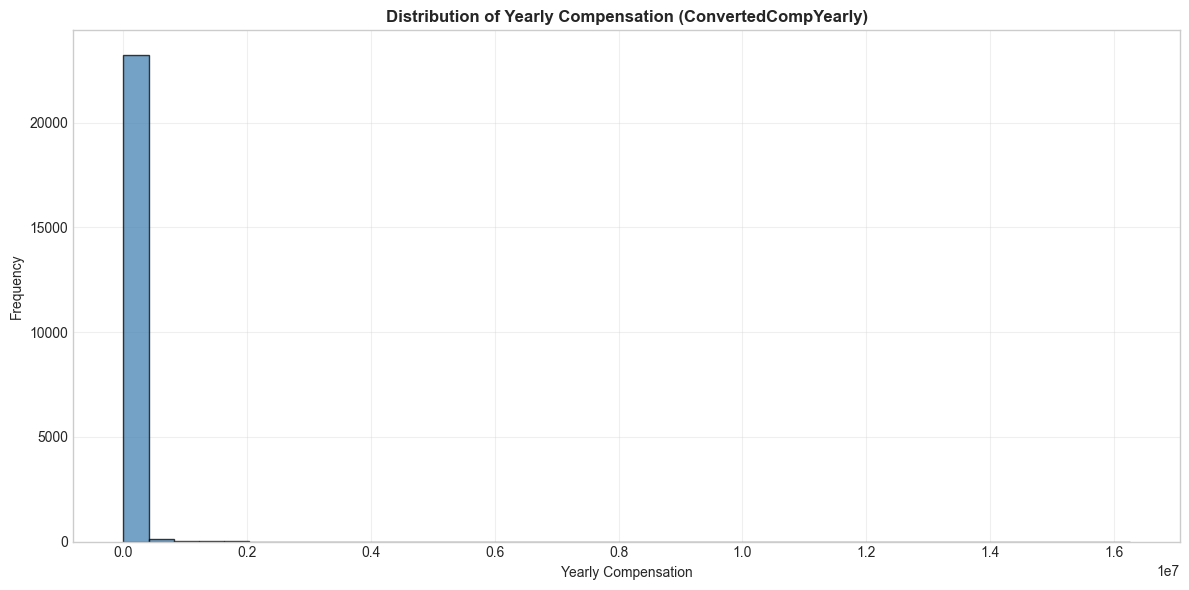

Count: 23,435 | Median: 65,000


In [4]:
comp = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce').dropna()
plt.figure(figsize=(12, 6))
plt.hist(comp, bins=40, color='steelblue', edgecolor='black', alpha=0.75)
plt.title('Distribution of Yearly Compensation (ConvertedCompYearly)', fontweight='bold')
plt.xlabel('Yearly Compensation')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Count: {len(comp):,} | Median: {comp.median():,.0f}')

### 2) Box Plot of `Age_numeric`
I'll plot the distribution of age (numeric mapping).

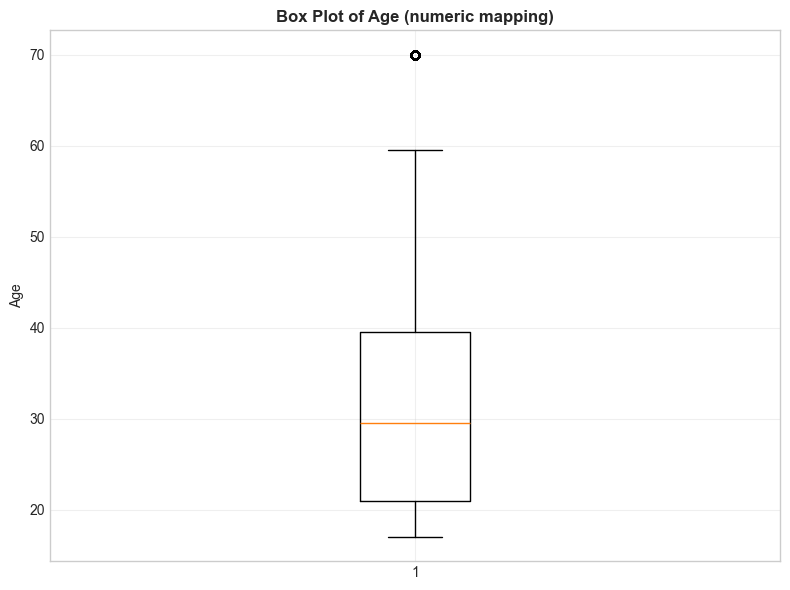

Age median: 29.5


In [5]:
age_num = df['Age_numeric'].dropna()
plt.figure(figsize=(8, 6))
plt.boxplot(age_num, vert=True)
plt.title('Box Plot of Age (numeric mapping)', fontweight='bold')
plt.ylabel('Age')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Age median: {age_num.median():.1f}')

## Task 2: Visualizing Relationships in Data

### 1) Scatter Plot: `Age_numeric` vs `ConvertedCompYearly`
I'll explore how compensation varies with age.

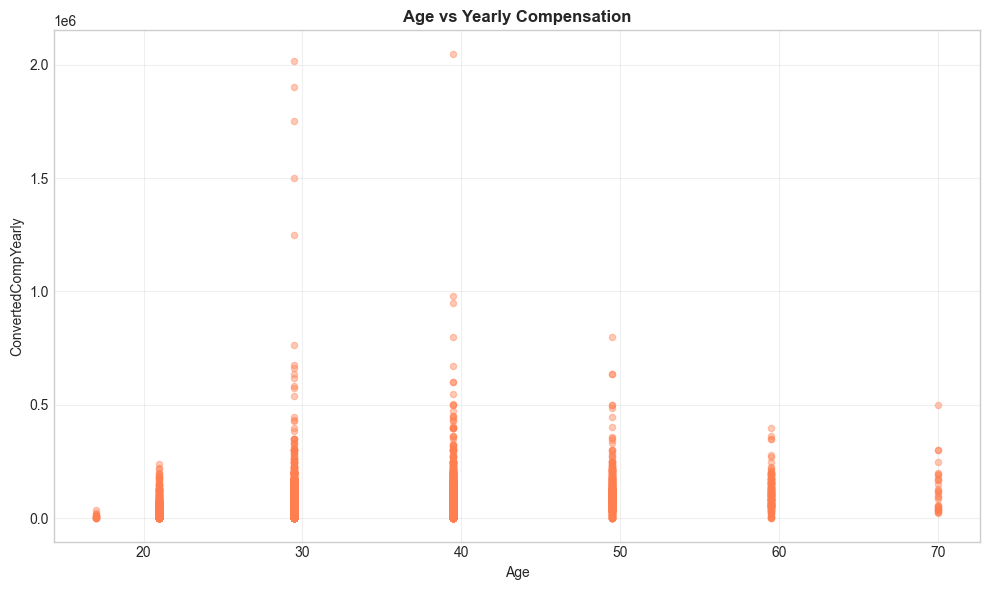

In [6]:
tmp = df[['Age_numeric', 'ConvertedCompYearly']].copy()
tmp['ConvertedCompYearly'] = pd.to_numeric(tmp['ConvertedCompYearly'], errors='coerce')
tmp = tmp.dropna()
if len(tmp) > 5000:
    tmp = tmp.sample(5000, random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(tmp['Age_numeric'], tmp['ConvertedCompYearly'], alpha=0.4, s=20, color='coral')
plt.title('Age vs Yearly Compensation', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('ConvertedCompYearly')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2) Bubble Plot: `ConvertedCompYearly` vs `JobSatPoints_6` (bubble size = age)
I'll examine compensation vs job satisfaction, using age as bubble size.

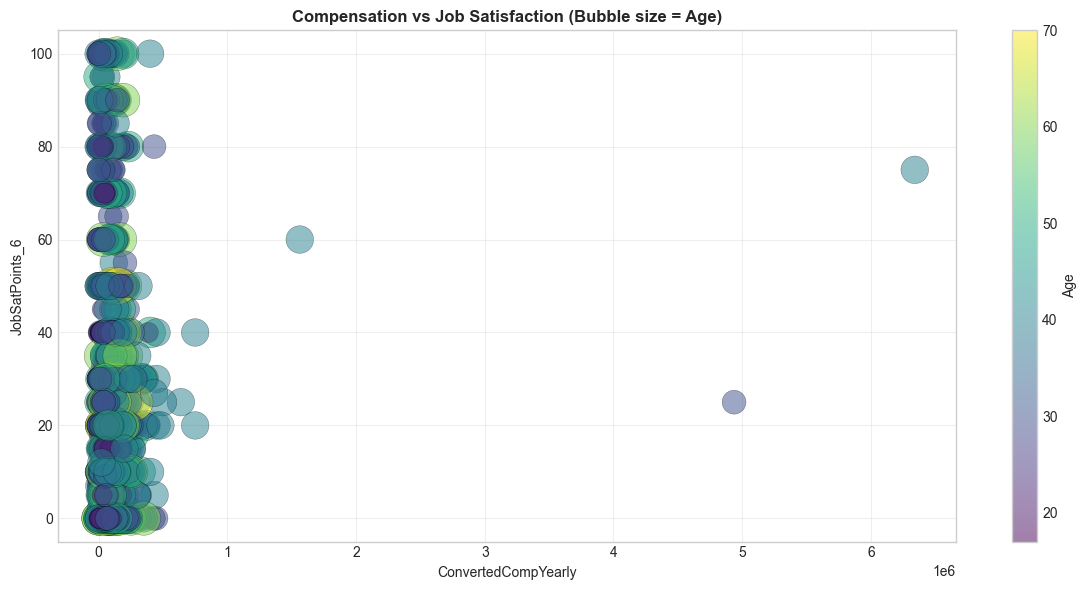

In [7]:
jobsat_col = 'JobSatPoints_6' if 'JobSatPoints_6' in df.columns else ('JobSat' if 'JobSat' in df.columns else None)
if jobsat_col is None:
    print('Job satisfaction column not found')
else:
    bub = df[['ConvertedCompYearly', jobsat_col, 'Age_numeric']].copy()
    bub['ConvertedCompYearly'] = pd.to_numeric(bub['ConvertedCompYearly'], errors='coerce')
    bub[jobsat_col] = pd.to_numeric(bub[jobsat_col], errors='coerce')
    bub = bub.dropna()
    if len(bub) > 2000:
        bub = bub.sample(2000, random_state=42)
    plt.figure(figsize=(12, 6))
    sc = plt.scatter(bub['ConvertedCompYearly'], bub[jobsat_col], s=bub['Age_numeric']*10,
                    c=bub['Age_numeric'], cmap='viridis', alpha=0.5, edgecolors='black', linewidth=0.3)
    plt.colorbar(sc, label='Age')
    plt.title('Compensation vs Job Satisfaction (Bubble size = Age)', fontweight='bold')
    plt.xlabel('ConvertedCompYearly')
    plt.ylabel(jobsat_col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Task 3: Visualizing Composition of Data with Bar Charts

### 1) Horizontal Bar Chart: `MainBranch` distribution

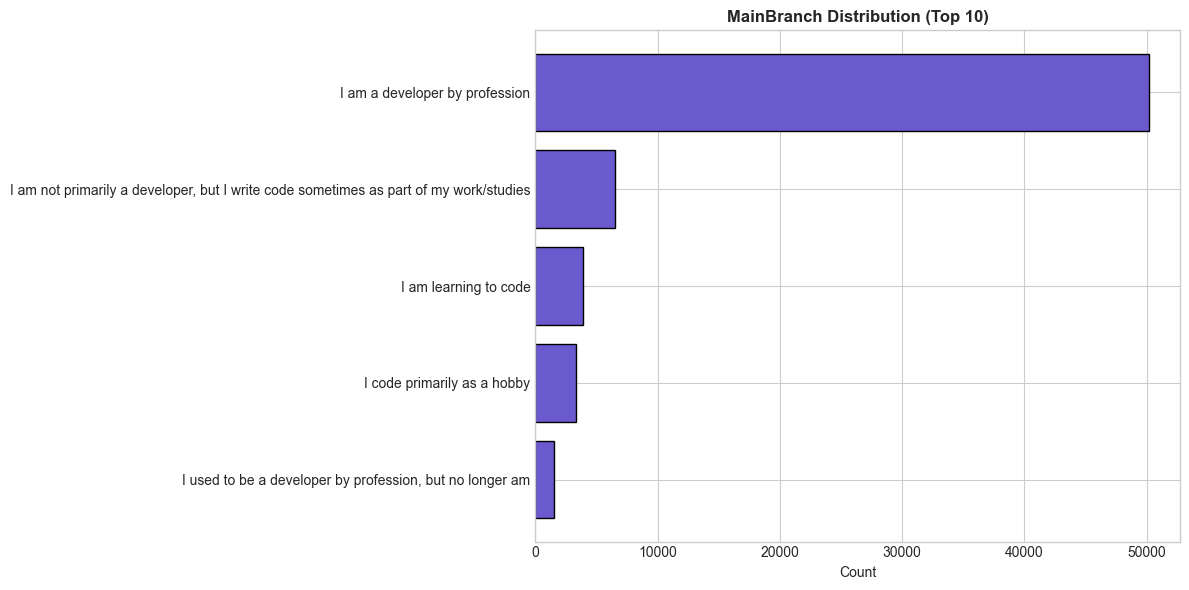

In [8]:
if 'MainBranch' in df.columns:
    mainbranch_counts = df['MainBranch'].value_counts().head(10).sort_values()
    plt.figure(figsize=(12, 6))
    plt.barh(mainbranch_counts.index, mainbranch_counts.values, color='slateblue', edgecolor='black')
    plt.title('MainBranch Distribution (Top 10)', fontweight='bold')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('MainBranch column not found')

### 2) Vertical Bar Chart: Top 5 `LanguageWantToWorkWith`

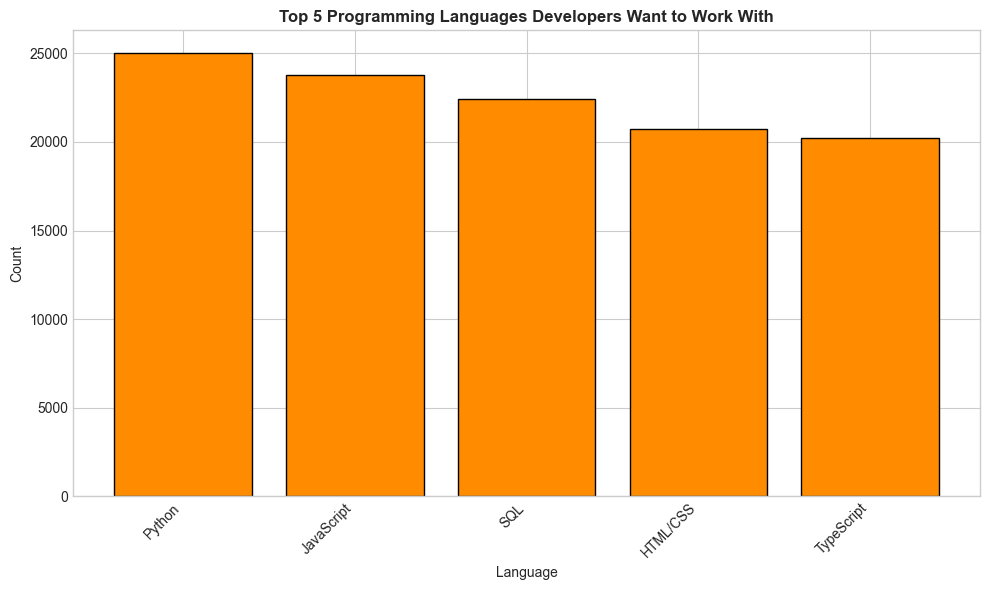

In [9]:
if 'LanguageWantToWorkWith' in df.columns:
    langs = df['LanguageWantToWorkWith'].dropna().str.split(';').explode()
    top_langs = langs.value_counts().head(5)
    plt.figure(figsize=(10, 6))
    plt.bar(top_langs.index, top_langs.values, color='darkorange', edgecolor='black')
    plt.title('Top 5 Programming Languages Developers Want to Work With', fontweight='bold')
    plt.xlabel('Language')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('LanguageWantToWorkWith column not found')

### 3) Stacked Bar Chart: Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group

In [10]:
if 'JobSatPoints_6' in df.columns and 'JobSatPoints_7' in df.columns:
    df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
    df['JobSatPoints_7'] = pd.to_numeric(df['JobSatPoints_7'], errors='coerce')
    # Filter to known age groups only (excludes 'Prefer not to say')
    df_known_age = df[df['Age_numeric'].notna()]
    med = df_known_age.groupby('Age')['JobSatPoints_6'].median()
    med2 = df_known_age.groupby('Age')['JobSatPoints_7'].median()
    tmp2 = pd.DataFrame({'JobSatPoints_6': med, 'JobSatPoints_7': med2}).dropna()
    # order by numeric mapping
    tmp2['Age_numeric'] = tmp2.index.map(age_mapping)
    tmp2 = tmp2.sort_values('Age_numeric')
    x = np.arange(len(tmp2))
    plt.figure(figsize=(12, 6))
    plt.bar(x, tmp2['JobSatPoints_6'], label='JobSatPoints_6', color='skyblue', edgecolor='black')
    plt.bar(x, tmp2['JobSatPoints_7'], bottom=tmp2['JobSatPoints_6'], label='JobSatPoints_7', color='salmon', edgecolor='black')
    plt.xticks(x, tmp2.index, rotation=45, ha='right')
    plt.title('Median Job Satisfaction Points by Age Group (Stacked)', fontweight='bold')
    plt.xlabel('Age Group')
    plt.ylabel('Median Points (stacked)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('JobSatPoints_6 and/or JobSatPoints_7 not found')

### 4) Bar Chart: Database popularity (`DatabaseHaveWorkedWith`)

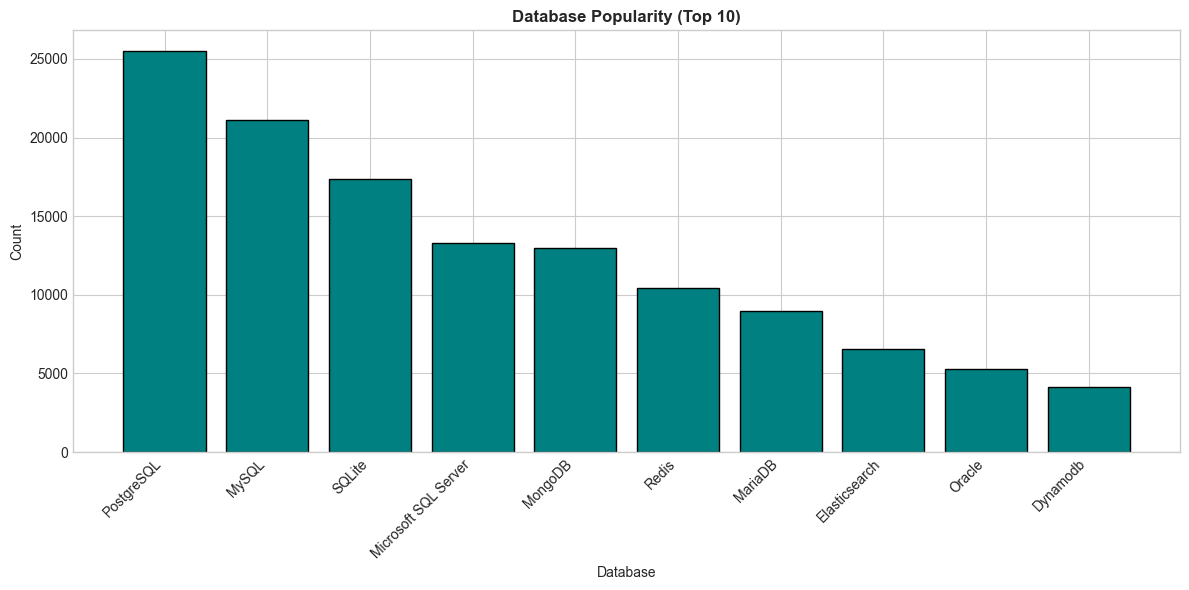

In [11]:
if 'DatabaseHaveWorkedWith' in df.columns:
    dbs = df['DatabaseHaveWorkedWith'].dropna().str.split(';').explode()
    top_dbs = dbs.value_counts().head(10)
    plt.figure(figsize=(12, 6))
    plt.bar(top_dbs.index, top_dbs.values, color='teal', edgecolor='black')
    plt.title('Database Popularity (Top 10)', fontweight='bold')
    plt.xlabel('Database')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('DatabaseHaveWorkedWith column not found')

## Task 4: Visualizing Comparison of Data with Bar Charts

### 1) Bar Chart: Median `ConvertedCompYearly` by Age Group

In [12]:
# Convert compensation to numeric in df (needed for groupby median to work)
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# Filter to known age groups only (excludes 'Prefer not to say')
df_known_age = df[df['Age_numeric'].notna()]
med_comp = df_known_age.groupby('Age')['ConvertedCompYearly'].median()
tmp3 = pd.DataFrame({'MedianComp': med_comp}).dropna()
tmp3['Age_numeric'] = tmp3.index.map(age_mapping)
tmp3 = tmp3.sort_values('Age_numeric')
plt.figure(figsize=(12, 6))
plt.bar(tmp3.index, tmp3['MedianComp'], color='mediumseagreen', edgecolor='black')
plt.title('Median Compensation by Age Group', fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Median ConvertedCompYearly')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2) Bar Chart: Respondent count by Country

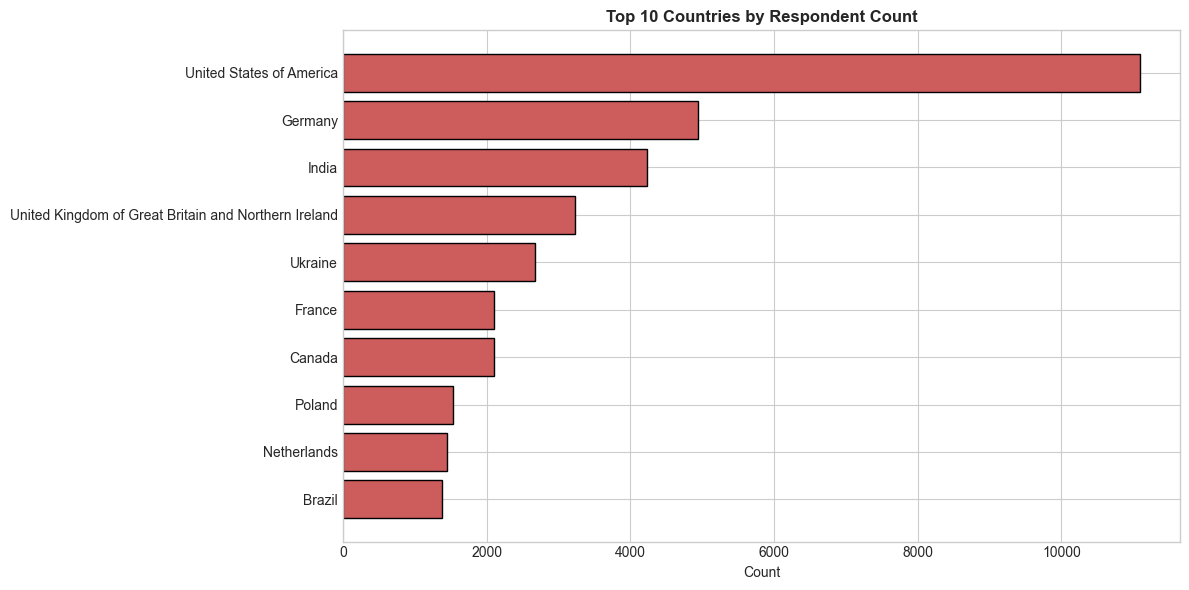

In [13]:
if 'Country' in df.columns:
    top_countries = df['Country'].value_counts().head(10).sort_values()
    plt.figure(figsize=(12, 6))
    plt.barh(top_countries.index, top_countries.values, color='indianred', edgecolor='black')
    plt.title('Top 10 Countries by Respondent Count', fontweight='bold')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('Country column not found')

## Summary

In this notebook, I created multiple plots including histograms, box plots, scatter plots, bubble plots, and several bar chart variants (horizontal, vertical, stacked, and grouped) to analyze distributions, relationships, composition, and comparisons in the survey dataset.